In [188]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

from diffusion import Diffusion
from dataset import DiffusionDataset, get_dataloader
from train import *

# Get dataset -> dataset, train_loader, test_loader, val_loader, d, scalers

In [273]:
## Initialisations
# Parameters
train_param = {
    'dataset_name': 'sin_1d',
    'x_normalise': True,
    'y_normalise': True,
    'seed': 42,
    'batch_size': 32,
    'train_ratio': 0.8,
    'val_ratio': 0.1,
    'shuffle': True,
    'T': 1000,
    'target': 'noise',
    'num_epochs': 100,
    'gp_lr': 0.01,
    'nn_lr': 0.0001,
    'optimiser': 'Adam',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}
plot_param = {
    'figsize': (7, 4),
    'grid_alpha': 0.5,
    'xlabel_fontsize': 12,
    'ylabel_fontsize': 12,
    'legend_fontsize': 11,
    'title_fontsize': 14,
    'xticks_fontsize': 11,
    'yticks_fontsize': 11,
    'scatter_size': 1,
}

In [274]:
## True underlying distribution for synthetic dataset
def f(x):
    return 1 + np.sin(2 * np.pi * x)
def sigma_y(x):
    return 0.5 + 0.4 * np.cos(6 * np.pi * x)

In [275]:
## Initialisations
dataset = DiffusionDataset(dataset_name=train_param['dataset_name'], x_normalise=train_param['x_normalise'], y_normalise=train_param['y_normalise'], seed=train_param['seed'])
train_loader, test_loader, val_loader = get_dataloader(dataset, batch_size=train_param['batch_size'], train_ratio=train_param['train_ratio'], val_ratio=train_param['val_ratio'], shuffle=train_param['shuffle'], seed=train_param['seed'], device=train_param['device'])
x_scaler, y_scaler = dataset.get_scalers()
d = Diffusion(T=train_param['T'])
print(f"Number of training batches: {len(train_loader)}, samples: {len(train_loader)*train_param['batch_size']}")
print(f"Number of validation batches: {len(val_loader)}, samples: {len(val_loader)*train_param['batch_size']}")
print(f"Number of test batches: {len(test_loader)}, samples: {len(test_loader)*train_param['batch_size']}")

Reshaping x from 1D to 2D, shape: (5000,) -> (5000, 1)
Reshaping y from 1D to 2D, shape: (5000,) -> (5000, 1)
Number of training batches: 125, samples: 4000
Number of validation batches: 16, samples: 512
Number of test batches: 16, samples: 512


# Vanilla GPs -> Homo + Hetero GP

### Homoscedastic GP

In [192]:
import gpytorch

## Exact GP models for GP baselines, computes analytically exact posterior and marginal likelihood
class MeanGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(MeanGPModel, self).__init__(train_x, train_y, likelihood) # pass train_x, train_y, likelihood to parent class
        # define components of prior GP, p(f(x))
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
    def forward(self, x):
        # returns distribution over function values f(x), prior distirbution
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
class NoiseGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(NoiseGP, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [193]:
## Flatten dataset for GP training
train_dataset = dataset[train_loader.dataset.indices]
test_dataset = dataset[test_loader.dataset.indices]
val_dataset = dataset[val_loader.dataset.indices]
train_x, train_y = train_dataset['x'].flatten(), train_dataset['y'].flatten() # y must be 1D for GP training
test_x, test_y = test_dataset['x'].flatten(), test_dataset['y'].flatten()
val_x, val_y = val_dataset['x'].flatten(), val_dataset['y'].flatten()

# Get true test y for rmse calculations
true_test_y = y_scaler.transform(f(x_scaler.inverse_transform(test_x.reshape(-1, 1)))).flatten() # for rmse calculations
true_test_y = torch.tensor(true_test_y, dtype=torch.float32)

print(train_x.shape, train_y.shape, test_x.shape, test_y.shape)

torch.Size([4000]) torch.Size([4000]) torch.Size([500]) torch.Size([500])


In [194]:
## Training & Evaluation over 5 runs
num_trials = 1
rmses = torch.zeros(num_trials)
nlls = torch.zeros(num_trials)

for i in range(num_trials):
    print(f"Trial {i+1} of {num_trials}")
    mean_model, mean_likelihood = train_exact_gp(gp_model=MeanGPModel, train_x=train_x, train_y=train_y, lr=train_param['gp_lr'], training_iter=200, report_iter=300)
    rmse, nll = eval_exact_gp(model=mean_model, likelihood=mean_likelihood, test_x=test_x, test_y=test_y, true_y=true_test_y)
    rmses[i] = rmse
    nlls[i] = nll
    
print('Ensemble results:')
print(f"RMSE: {rmses.mean()} ± {rmses.std()}")
print(f"NLL: {nlls.mean()} ± {nlls.std()}")

Trial 1 of 1
Intial parameters of GP model - lengthscale: 0.693   noise: 0.693   outputscale: 0.693
Iter 1/200 - Loss: 1.042   lengthscale: 0.698   noise: 0.688   outputscale: 0.688
Trained parameters of GP model - lengthscale: 0.792   noise: 0.419   outputscale: 0.545
RMSE: 0.044332098215818405
NLL: 0.4869615435600281
Ensemble results:
RMSE: 0.044332098215818405 ± nan
NLL: 0.4869615435600281 ± nan


/var/folders/sq/_ygl92r55ks2__x_h38qg7h00000gn/T/ipykernel_18038/51580241.py:14: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  print(f"RMSE: {rmses.mean()} ± {rmses.std()}")
/var/folders/sq/_ygl92r55ks2__x_h38qg7h00000gn/T/ipykernel_18038/51580241.py:15: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  print(f"NLL: {nlls.mean()} ± {nlls.std()}")


In [11]:
# save the mean model and mean likelihood
torch.save({
    'model_state_dict': mean_model.state_dict(),
    'likelihood_state_dict': mean_likelihood.state_dict()
}, 'synthetic_models/mean_gp.pt')

In [195]:
# Load the mean model and mean likelihood
mean_likelihood = gpytorch.likelihoods.GaussianLikelihood()
mean_model = MeanGPModel(train_x, train_y, mean_likelihood)

# Load the mean model and mean likelihood
checkpoint = torch.load('synthetic_models/mean_gp.pt')
mean_model.load_state_dict(checkpoint['model_state_dict'])
mean_likelihood.load_state_dict(checkpoint['likelihood_state_dict'])

<All keys matched successfully>

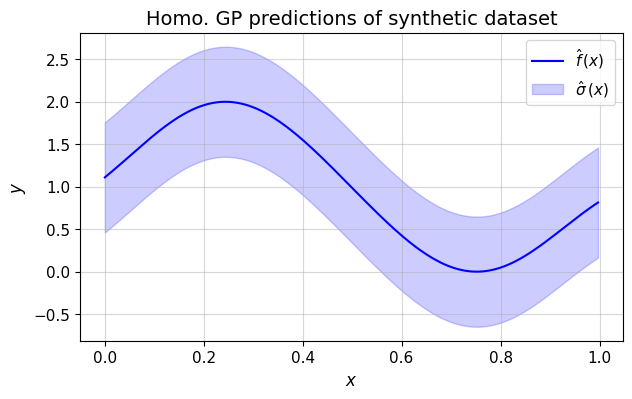

In [196]:
# Visualises predictions
mean_model.eval()
mean_likelihood.eval()
with torch.no_grad():
    mean_preds = mean_model(test_x).mean.detach().numpy()
    epi_var = mean_model(test_x).variance.detach().numpy()
    alo_var = mean_likelihood(mean_model(test_x)).variance.detach().numpy() - epi_var
mean_plot = y_scaler.inverse_transform(mean_preds.reshape(-1, 1)).flatten()
x_plot = x_scaler.inverse_transform(test_x.reshape(-1, 1)).flatten()

plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.plot(x_plot[np.argsort(x_plot)], mean_plot[np.argsort(x_plot)], 'b-', label=r'$\hat{f}\,(x)$')
plt.fill_between(x_plot[np.argsort(x_plot)], mean_plot[np.argsort(x_plot)] - np.sqrt(alo_var[np.argsort(x_plot)]), mean_plot[np.argsort(x_plot)] + np.sqrt(alo_var[np.argsort(x_plot)]), color='b', alpha=0.2, label=r'$\hat{\sigma}\,(x)$')
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.title('Homo. GP predictions of synthetic dataset', fontsize=plot_param['title_fontsize'])
plt.xlabel(r'$x$', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel(r'$y$', fontsize=plot_param['ylabel_fontsize'])
plt.legend(fontsize=plot_param['legend_fontsize'])

### Hetero GP

/opt/anaconda3/envs/dgp/lib/python3.11/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


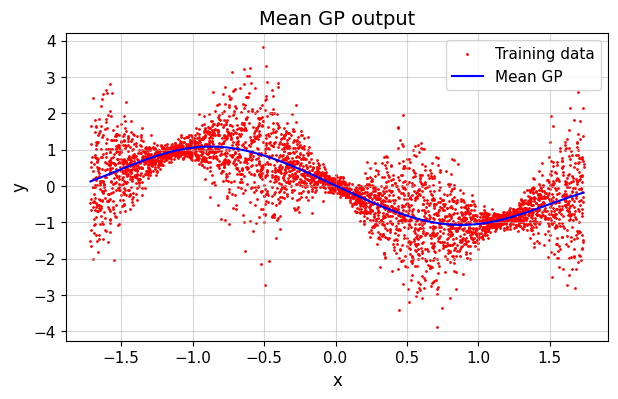

In [197]:
# Set the mean model to evaluation mode
mean_model.eval()
mean_likelihood.eval()
with torch.no_grad():
    mean_pred = mean_model(train_x).mean

plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.scatter(train_x[np.argsort(train_x)], train_y[np.argsort(train_x)], c='r', label='Training data', s=1)
plt.plot(train_x[np.argsort(train_x)], mean_pred[np.argsort(train_x)], c='b', label='Mean GP')
plt.legend(fontsize=plot_param['legend_fontsize'])
plt.title('Mean GP output', fontsize=plot_param['title_fontsize'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.show()

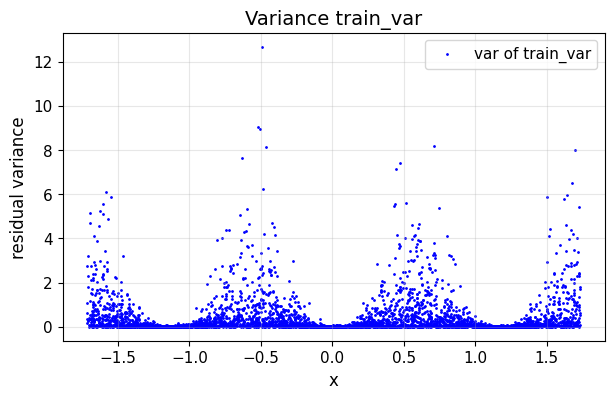

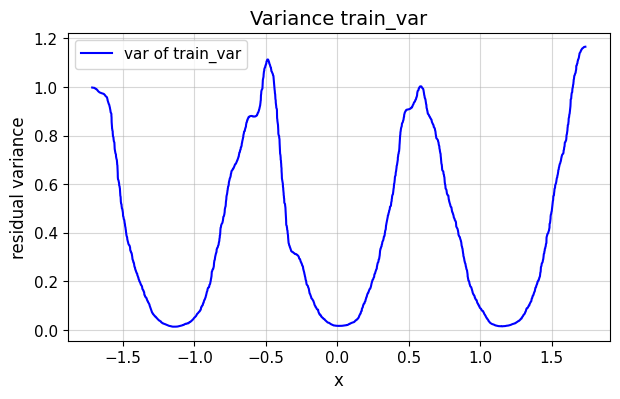

In [199]:
train_var = (train_y - mean_pred)**2
plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=0.3)
plt.scatter(train_x, train_var, c='b', label='var of train_var', s=1)
plt.title('Variance train_var', fontsize=plot_param['title_fontsize'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('residual variance', fontsize=plot_param['ylabel_fontsize'])
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.legend(fontsize=plot_param['legend_fontsize'])
plt.show()

from scipy.ndimage import gaussian_filter
smoothed_train_var = torch.tensor(gaussian_filter(train_var[np.argsort(train_x)], sigma=50))
sorted_train_x = train_x[np.argsort(train_x)]
plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.plot(sorted_train_x, smoothed_train_var, c='b', label='var of train_var')
plt.title('Variance train_var', fontsize=plot_param['title_fontsize'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('residual variance', fontsize=plot_param['ylabel_fontsize'])
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.legend(fontsize=plot_param['legend_fontsize'])
plt.show()

log_train_var = torch.log(smoothed_train_var) # for training

In [200]:
noise_model, noise_likelihood = train_exact_gp(gp_model=NoiseGP, train_x=sorted_train_x, train_y=log_train_var, lr=train_param['gp_lr'], training_iter=200, report_iter=50)

Intial parameters of GP model - lengthscale: 0.693   noise: 0.693   outputscale: 0.693
Iter 1/200 - Loss: 1.175   lengthscale: 0.688   noise: 0.688   outputscale: 0.698
Iter 51/200 - Loss: 0.715   lengthscale: 0.513   noise: 0.457   outputscale: 0.921
Iter 101/200 - Loss: 0.514   lengthscale: 0.442   noise: 0.293   outputscale: 1.052
Iter 151/200 - Loss: 0.158   lengthscale: 0.324   noise: 0.176   outputscale: 1.226
Trained parameters of GP model - lengthscale: 0.271   noise: 0.100   outputscale: 1.328


In [201]:
# save the mean model and mean likelihood
torch.save({
    'model_state_dict': noise_model.state_dict(),
    'likelihood_state_dict': noise_likelihood.state_dict()
}, 'synthetic_models/noise_gp.pt')

In [ ]:
# Load the mean model and mean likelihood
noise_likelihood = gpytorch.likelihoods.GaussianLikelihood()
noise_model = NoiseGP(sorted_train_x, log_train_var, noise_likelihood)

# Load the mean model and mean likelihood
checkpoint = torch.load('synthetic_models/noise_gp.pt')
noise_model.load_state_dict(checkpoint['model_state_dict'])
noise_likelihood.load_state_dict(checkpoint['likelihood_state_dict'])

In [207]:
mean_model.eval()
mean_likelihood.eval()
noise_model.eval()
noise_likelihood.eval()

with torch.no_grad():
    mean_pred = mean_model(test_x).mean
    noise_pred = torch.exp(noise_model(test_x).mean)
    mean_epi_pred = mean_model(test_x).variance
    noise_epi_pred = noise_model(test_x).variance
    total_epi_pred = mean_epi_pred + noise_epi_pred

rmse = evaluate_metrics(pred_mean=mean_pred, pred_var=noise_pred, test_y=test_y, true_y=true_test_y, type='rmse')
nll = evaluate_metrics(pred_mean=mean_pred, pred_var=noise_pred, test_y=test_y, true_y=true_test_y, type='nll')

print(f"RMSE: {rmse}")
print(f"NLL: {nll}")

RMSE: 0.044332098215818405
NLL: 0.1535203605890274


In [211]:
total_epi_std = torch.sqrt(total_epi_pred)
total_epi_std = total_epi_std.detach().numpy()

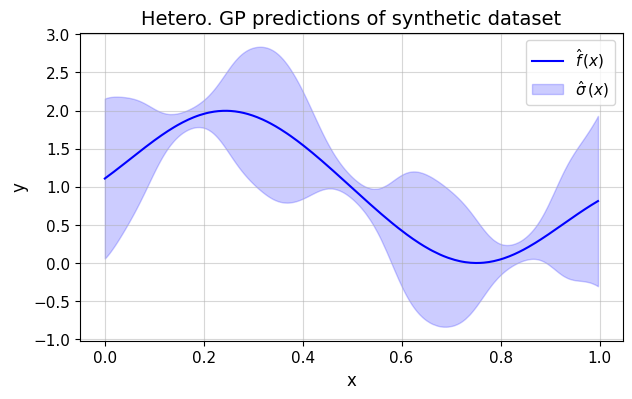

In [213]:
x_plot = test_x[np.argsort(test_x)]
x_plot = x_scaler.inverse_transform(x_plot.reshape(-1, 1)).flatten()
mean_plot = mean_pred[np.argsort(test_x)]
mean_plot = y_scaler.inverse_transform(mean_plot.reshape(-1, 1)).flatten()
noise_plot = noise_pred[np.argsort(test_x)].detach().numpy()

plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.plot(x_plot, mean_plot, 'b-', label=r'$\hat{f}\,(x)$')
plt.fill_between(x_plot, mean_plot - noise_plot**0.5, mean_plot + noise_plot**0.5, color='b', alpha=0.2, label=r'$\hat{\sigma}\,(x)$')
# plt.fill_between(x_plot, mean_plot - total_epi_std[np.argsort(test_x)], mean_plot + total_epi_std[np.argsort(test_x)], color='r', alpha=0.2, label=r'$\hat{\sigma}\,(x)$')
plt.title('Hetero. GP predictions of synthetic dataset', fontsize=plot_param['title_fontsize'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.legend(fontsize=plot_param['legend_fontsize'])
# plt.ylim(-2.5, 4)
plt.show()

# Diffusion GP

In [217]:
def get_t_embedding(t: torch.Tensor, time_embed_dim: int) -> torch.Tensor:
    """
    Sinusoidal time embedding.
    Inputs:
      t: (batch_size, 1)
      time_embed_dim: int
    Output:
      (batch_size, time_embed_dim)
    """
    half_dim = time_embed_dim // 2 
    omegas = torch.exp(-torch.log(torch.tensor(10000.0)) * 2*torch.arange(half_dim) / (half_dim*2))
    embedding = torch.empty(t.shape[0], time_embed_dim)
    for i in range(t.shape[0]):
        embedding[i] = torch.cat([torch.sin(t[i] * omegas), torch.cos(t[i] * omegas)], dim=0)
    return embedding

## SVGP

In [218]:
import gpytorch

class SVGP(gpytorch.models.ApproximateGP):
    def __init__(self, num_inducing_points, input_dim, mean_type = 'linear', matern_nu=[1.5, 1.5, 1.5]):
        inducing_points = torch.rand(num_inducing_points, input_dim) # input dim is concatenation of x, y_t, t
        variational_dist = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_dist, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)
        # Initialise mean module
        if mean_type == 'linear':
            self.mean_module = gpytorch.means.LinearMean(input_size=input_dim)
        elif mean_type == 'constant':
            self.mean_module = gpytorch.means.ConstantMean(input_size=input_dim)
        elif mean_type == 'zero':
            self.mean_module = gpytorch.means.ZeroMean(input_size=input_dim)
        else:
            raise ValueError(f"Mean type {mean_type} not supported")
        # Initialise covariance module
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.ProductKernel(
                gpytorch.kernels.MaternKernel(nu=matern_nu[0], active_dims=list(range(input_dim-2))),  # x
                gpytorch.kernels.MaternKernel(nu=matern_nu[1], active_dims=input_dim-2),  # y_t
                gpytorch.kernels.MaternKernel(nu=matern_nu[2], active_dims=input_dim-1),   # t
            ), 
        )
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [219]:
def sample_dgp(model, likelihood, diffusion, x, y_t, clamp=False, clamp_mag=5.0):
    model.eval()
    likelihood.eval()
    alo_y_t = y_t.clone()
    epi_y_t = y_t.clone()

    with torch.no_grad():
        for t in range(d.T-1, -1, -1): # reverse time steps
            t_tensor = torch.ones_like(y_t, dtype=torch.float32) * (t+1) / d.T # normalise time step
            noise = torch.randn_like(y_t)
            alo_z = torch.cat([x, alo_y_t, t_tensor], dim=1)
            epi_z = torch.cat([x, epi_y_t, t_tensor], dim=1)
            alo_output = model(alo_z)
            epi_output = model(epi_z)
            alo_score = alo_output.mean.reshape(y_t.shape)
            epi_score = epi_output.mean + torch.randn_like(epi_output.mean) * torch.sqrt(epi_output.variance)
            epi_score = epi_score.reshape(y_t.shape)
            alo_y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (alo_y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * alo_score) # update y_t
            alo_y_t += noise * torch.sqrt(diffusion.betas[t]) # add noise
            epi_y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (epi_y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * epi_score) # update y_t

            if clamp:
                alo_y_t = torch.clamp(alo_y_t, min=-clamp_mag, max=clamp_mag)
                epi_y_t = torch.clamp(epi_y_t, min=-clamp_mag, max=clamp_mag)
    return alo_y_t, epi_y_t
            

In [220]:
num_inducing_points = 1000
input_dim = dataset.x.shape[1] + 2
update_freq = 10

svgp_model = SVGP(num_inducing_points=num_inducing_points, input_dim=input_dim, mean_type='linear', matern_nu=[2.5, 2.5, 2.5]).to(train_param['device'])
svgp_likelihood = gpytorch.likelihoods.GaussianLikelihood().to(train_param['device'])
optimiser = torch.optim.Adam(svgp_model.parameters(), lr=train_param['gp_lr'])
train_losses = []
val_losses = []

with tqdm(total=train_param['num_epochs']) as pbar:
    for epoch in range(train_param['num_epochs']):
        ## Training phase
        svgp_model.train()
        svgp_likelihood.train()
        loss_fn = gpytorch.mlls.VariationalELBO(svgp_likelihood, svgp_model, num_data=len(train_loader.dataset))
        train_loss = 0
        train_num_batches = 0
        for batch in train_loader:
            x = batch['x']
            y_0 = batch['y']
            t = torch.randint(1, d.T, (y_0.shape[0], 1), device=train_param['device'])
            noise = torch.randn_like(y_0, device=train_param['device'])
            y_t = d.sample_q(y_0, t, noise)
            assert x.dim() == y_0.dim() == t.dim() == y_t.dim(), "x, y_0, t, y_t must have the same dimension" # check x, y_0, t have the same dimensions
            t_norm = t / d.T # normalise time step
            z = torch.cat([x, y_t, t_norm], dim=1) # input to the gp model
            score = svgp_model(z)
            loss = -loss_fn(score, noise[:,0])
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            train_loss += loss.item()
            train_num_batches += 1
        train_losses.append(train_loss / train_num_batches)
        
        ## Validation phase
        svgp_model.eval()
        svgp_likelihood.eval()
        val_loss = 0
        val_num_batches = 0
        for batch in val_loader:
            x = batch['x']
            y_0 = batch['y']
            t = torch.randint(1, d.T, (y_0.shape[0], 1), device=train_param['device'])
            noise = torch.randn_like(y_0, device=train_param['device'])
            y_t = d.sample_q(y_0, t, noise)
            assert x.dim() == y_0.dim() == t.dim() == y_t.dim(), "x, y_0, t, y_t must have the same dimension" # check x, y_0, t have the same dimensions
            t_norm = t / d.T # normalise time step
            z = torch.cat([x, y_t, t_norm], dim=1) # input to the gp model
            score = svgp_model(z)
            loss = -loss_fn(score, noise[:,0])
            val_loss += loss.item()
            val_num_batches += 1
        val_losses.append(val_loss / val_num_batches)

        if epoch % update_freq == 0:
            print(f"Epoch {epoch}, Train loss: {train_losses[-1]}, Val loss: {val_losses[-1]}")
            # print out lengthscale
            print(f"Lengthscales: x - {svgp_model.covar_module.base_kernel.kernels[0].lengthscale.item()}, y_t - {svgp_model.covar_module.base_kernel.kernels[1].lengthscale.item()}, t - {svgp_model.covar_module.base_kernel.kernels[2].lengthscale.item()}")
            print(f"Outputscale: {svgp_model.covar_module.outputscale.item()}")
        pbar.update(1)

  1%|          | 1/100 [00:06<10:44,  6.51s/it]

Epoch 0, Train loss: 1.4426156730651856, Val loss: 1.0884017199277878
Lengthscales: x - 1.2086800336837769, y_t - 1.2549620866775513, t - 0.9014794826507568
Outputscale: 0.44136378169059753


 11%|█         | 11/100 [01:11<09:32,  6.43s/it]

Epoch 10, Train loss: 1.022880886554718, Val loss: 1.0866939797997475
Lengthscales: x - 1.1418153047561646, y_t - 2.0500476360321045, t - 0.7700645923614502
Outputscale: 0.2845686972141266


 21%|██        | 21/100 [02:16<08:29,  6.45s/it]

...

 81%|████████  | 81/100 [08:52<02:06,  6.64s/it]

Epoch 80, Train loss: 1.019837426662445, Val loss: 1.0187085531651974
Lengthscales: x - 0.4060173034667969, y_t - 1.9127085208892822, t - 0.6802988648414612
Outputscale: 0.1702161580324173


 91%|█████████ | 91/100 [10:00<01:02,  6.92s/it]

Epoch 90, Train loss: 1.0175231623649597, Val loss: 1.0455447621643543
Lengthscales: x - 0.413618266582489, y_t - 1.944968581199646, t - 0.6719453930854797
Outputscale: 0.1748959720134735


100%|██████████| 100/100 [11:02<00:00,  6.63s/it]


In [135]:
# Save model and likelihood
torch.save({
    'model_state_dict': svgp_model.state_dict(),
    'likelihood_state_dict': svgp_likelihood.state_dict()
}, 'synthetic_models/svgp_model.pth')

In [224]:
x_locations = torch.linspace(0, 1, 200).reshape(-1, 1)
x_locations = torch.tensor(x_scaler.transform(x_locations), dtype=torch.float32)
num_samples = 100
alo_samples = torch.zeros(x_locations.shape[0], num_samples, device=train_param['device'], dtype=torch.float32)
epi_samples = torch.zeros(x_locations.shape[0], num_samples, device=train_param['device'], dtype=torch.float32)

svgp_model.eval()
svgp_likelihood.eval()
with tqdm(total=num_samples) as pbar:
    with torch.no_grad():
        for i in range(num_samples):
            y_t = torch.randn_like(torch.zeros(x_locations.shape[0], 1), device=train_param['device'], dtype=torch.float32)
            alo_y_t, epi_y_t = sample_dgp(model=svgp_model, likelihood=svgp_likelihood, diffusion=d, x=x_locations, y_t=y_t, clamp=False, clamp_mag=5)
            alo_samples[:, i] = alo_y_t[:,0]
            epi_samples[:, i] = epi_y_t[:,0]
            pbar.update(1)

100%|██████████| 100/100 [11:59<00:00,  7.19s/it]


In [225]:
x_locations_og = torch.tensor(x_scaler.inverse_transform(x_locations))
alo_samples_og = torch.tensor(y_scaler.inverse_transform(alo_samples))
epi_samples_og = torch.tensor(y_scaler.inverse_transform(epi_samples))

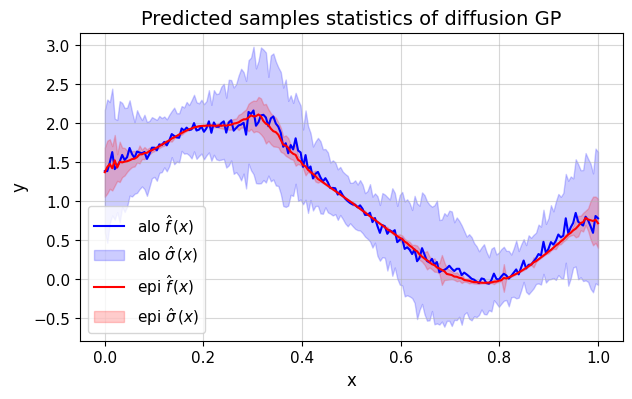

In [226]:
alo_sample_mean = torch.mean(alo_samples_og, axis=1)
alo_sample_std = torch.std(alo_samples_og, axis=1)
epi_sample_mean = torch.mean(epi_samples_og, axis=1)
epi_sample_std = torch.std(epi_samples_og, axis=1)

plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.title('Predicted samples statistics of diffusion GP', fontsize=plot_param['title_fontsize'])
plt.plot(x_locations_og, alo_sample_mean, label=r'alo $\hat{f}\,(x)$', c='b', linewidth=1.5)
plt.fill_between(x_locations_og[:,0], alo_sample_mean - alo_sample_std, alo_sample_mean + alo_sample_std, alpha=0.2, label=r'alo $\hat{\sigma}\,(x)$', color='b')
plt.plot(x_locations_og, epi_sample_mean, label=r'epi $\hat{f}\,(x)$', c='r', linewidth=1.5)
plt.fill_between(x_locations_og[:,0], epi_sample_mean - epi_sample_std, epi_sample_mean + epi_sample_std, alpha=0.2, label=r'epi $\hat{\sigma}\,(x)$', color='r')
plt.legend(fontsize=plot_param['legend_fontsize'], loc='lower left')
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.show()


In [184]:
epi_sample_std

tensor([0.5973, 0.5565, 0.4595, 0.5607, 0.3955, 0.3695, 0.3307, 0.4719, 0.3362,
        0.3203, 0.2434, 0.1985, 0.1273, 0.1867, 0.2117, 0.1375, 0.0835, 0.0838,
        0.0549, 0.0758, 0.0851, 0.0331, 0.0415, 0.0520, 0.0115, 0.0156, 0.0347,
        0.0089, 0.0152, 0.0201, 0.0083, 0.0106, 0.0087, 0.0096, 0.0106, 0.0140,
        0.0531, 0.0225, 0.0094, 0.0067, 0.0168, 0.0141, 0.0152, 0.0245, 0.0215,
        0.0609, 0.0203, 0.0298, 0.0234, 0.0453, 0.0549, 0.0468, 0.0582, 0.0945,
        0.0960, 0.0977, 0.0937, 0.1247, 0.1373, 0.1977, 0.1667, 0.1085, 0.2263,
        0.1553, 0.1624, 0.2453, 0.2144, 0.2306, 0.2704, 0.1885, 0.2611, 0.2641,
        0.2077, 0.1364, 0.1496, 0.1725, 0.1575, 0.1095, 0.0746, 0.0526, 0.1144,
        0.1321, 0.0515, 0.0931, 0.0566, 0.0436, 0.1004, 0.0146, 0.0539, 0.0222,
        0.0119, 0.0194, 0.0121, 0.0151, 0.0081, 0.0068, 0.0089, 0.0219, 0.0130,
        0.0072, 0.0125, 0.0067, 0.0050, 0.0084, 0.0088, 0.0220, 0.0068, 0.0147,
        0.0316, 0.0122, 0.0104, 0.0064, 

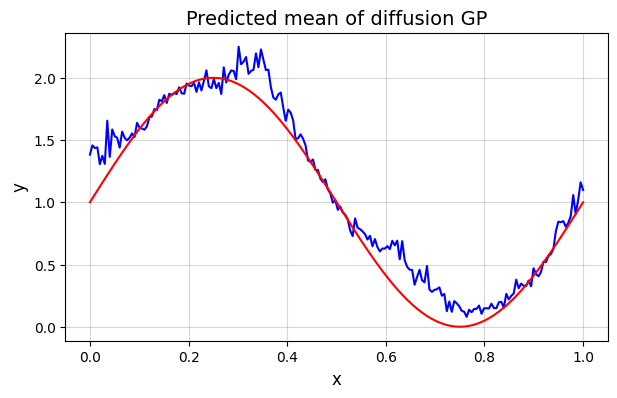

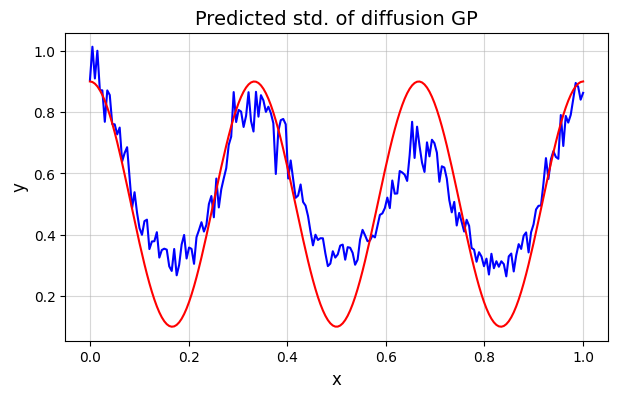

In [187]:
plt.figure(figsize=plot_param['figsize'])
plt.title('Predicted mean of diffusion GP', fontsize=plot_param['title_fontsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.plot(x_locations_og, alo_sample_mean, c='b')
plt.plot(x_locations_og, f(x_locations_og), c='r', linewidth=1.5)

plt.figure(figsize=plot_param['figsize'])
plt.title('Predicted std. of diffusion GP', fontsize=plot_param['title_fontsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.plot(x_locations_og, alo_sample_std, c='b')
plt.plot(x_locations_og, sigma_y(x_locations_og), c='r', linewidth=1.5)

In [233]:
y_T[0].shape

torch.Size([1, 1])

In [240]:
def sample_dgp(model, likelihood, diffusion, x, y_t, noise, clamp=False, clamp_mag=5.0):
    model.eval()
    likelihood.eval()
    # noise shape = (1000, 100, 1)
    # y_t shape = (100, 1)
    y_t1 = y_t.clone()

    with torch.no_grad():
        for t in range(d.T-1, -1, -1): # reverse time steps
            t_tensor = torch.ones_like(y_t1, dtype=torch.float32) * (t+1) / d.T # (batch_size, 1)
            z = torch.cat([x, y_t1, t_tensor], dim=1)
            output = model(z)
            score = output.mean + torch.randn_like(output.mean) * torch.sqrt(output.variance)
            score = score.reshape(y_t1.shape)
            y_t1 = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t1 - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score) # update y_t1
            y_t1 += noise[t] * torch.sqrt(diffusion.betas[t]) # add noise

            if clamp:
                y_t1 = torch.clamp(y_t1, min=-clamp_mag, max=clamp_mag)
    return y_t1 

In [266]:
exp_it = 20
x = torch.linspace(0, 1, 100).reshape(-1, 1) # shape (100, 1)
x = torch.tensor(x_scaler.transform(x), dtype=torch.float32)
y_T = torch.randn(exp_it, 100, 1)  
Z = torch.randn(exp_it, 1000, 100, 1)

In [267]:
var_it = 10
exp_results = torch.empty(y_T.shape[0], x.shape[0]) # shape (50, 100)

with tqdm(total=y_T.shape[0] * var_it) as pbar:
    for i in range(y_T.shape[0]):
        y_t = y_T[i] # shape (100, 1)
        noise = Z[i] # shape (1000, 100, 1)
        var_results = torch.empty(var_it, y_T.shape[1])
        for j in range(var_it):
            var_results[j] = sample_dgp(model=svgp_model, likelihood=svgp_likelihood, diffusion=d, x=x, y_t=y_t, noise=noise)[:,0]
            pbar.update(1)
        exp_results[i] = var_results.var(dim=0)

100%|██████████| 200/200 [08:55<00:00,  2.68s/it]


In [268]:
exp_mean = exp_results.mean(dim=0)
exp_std = torch.sqrt(exp_mean)

In [271]:
x = x_scaler.inverse_transform(x)

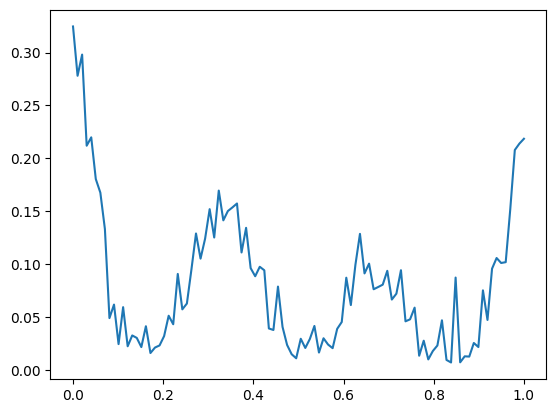

In [272]:
plt.plot(x, exp_std)